# 04: Timecourse Classification Analysis
## CNN Accuracy Across All Timepoints (t=0 to t=14)

Can we see different perfomance of the models depending on which time point we use?

## Setup & Imports

In [15]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import warnings

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# GPU
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Paths
DATA_DIR = Path('/baldig/bioprojects2/emartinl/chemores/preprocessed_phasor')
RESULTS_DIR = Path('/home/emartinl/chemores/results')
RESULTS_DIR.mkdir(exist_ok=True)

# File info - 2 original files only (multi-timepoint, both sessions same)
FILE_INFO = {
    'CNTL-MB231':     {'group': 'Control',         'session': 0, 'idx': 0},
    'TAMO-MB231':     {'group': 'Chemoresistant',  'session': 0, 'idx': 1},
}

Device: cuda:0
GPU: NVIDIA RTX 6000 Ada Generation
Memory: 50.9 GB


## Data Loading (Reuse from 03_modeling)

In [ ]:
class CellImageDataset(Dataset):
    """Lazy-load cell images with optional resizing and normalization."""
    
    def __init__(self, file_name, data_dir, group_label, session_label, 
                 timepoint=0, target_size=64, normalize=True):
        self.npy_path = data_dir / f"{file_name}_cells.npy"
        self.csv_path = data_dir / f"{file_name}_cells_meta.csv"
        self.group_label = group_label  # 0=Control, 1=Chemo
        self.session_label = session_label
        self.timepoint = timepoint
        self.target_size = target_size
        self.normalize = normalize
        
        # Load metadata
        self.metadata = pd.read_csv(self.csv_path)
        # Filter by timepoint
        self.metadata = self.metadata[self.metadata['time'] == self.timepoint].reset_index(drop=True)
        
        # Load array shape info
        temp = np.load(self.npy_path, mmap_mode='r')
        self.array_shape = temp.shape
        del temp
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        cell_idx = int(row['cell_id'])
        
        # Load image
        data = np.load(self.npy_path, mmap_mode='r')
        crop = data[cell_idx].astype(np.float32)
        
        # Resize if needed
        if crop.shape != (7, self.target_size, self.target_size):
            crop_resized = np.zeros((7, self.target_size, self.target_size), dtype=np.float32)
            for c in range(7):
                from scipy.ndimage import zoom
                scale = self.target_size / crop.shape[1]
                crop_resized[c] = zoom(crop[c], scale, order=1)
            crop = crop_resized
        
        # Normalize per-channel
        if self.normalize:
            for c in range(7):
                ch = crop[c]
                if ch.max() > ch.min():
                    crop[c] = (ch - ch.min()) / (ch.max() - ch.min())
        
        return torch.from_numpy(crop), self.group_label


def load_dataset_for_timepoint(timepoint, target_size=64, files=None):
    """Load all files for a given timepoint."""
    if files is None:
        files = FILE_INFO
    
    datasets = []
    
    for file_name, info in files.items():
        csv_path = DATA_DIR / f"{file_name}_cells_meta.csv"
        if csv_path.exists():
            ds = CellImageDataset(
                file_name=file_name,
                data_dir=DATA_DIR,
                group_label=1 if info['group'] == 'Chemoresistant' else 0,
                session_label=info['session'],
                timepoint=timepoint,
                target_size=target_size,
                normalize=True
            )
            if len(ds) > 0:
                datasets.append(ds)
    
    if len(datasets) == 0:
        return None
    
    return ConcatDataset(datasets)

print("Dataset loading functions defined.")

## CNN Architecture (SmallCNN from 03_modeling)

In [ ]:
class SmallCNN(nn.Module):
    """Simple CNN for classification."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(7, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

## Training & Evaluation Functions

In [ ]:
def train_epoch(model, train_loader, optimizer, device='cpu'):
    """Train one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    return {
        'loss': total_loss / len(train_loader),
        'accuracy': correct / total
    }

def evaluate(model, eval_loader, device='cpu'):
    """Evaluate model."""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in eval_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    return correct / total

## Stratified Random Split for 2-file Dataset

In [ ]:
def stratified_random_split(dataset, n_splits=5, random_state=42):
    """Create stratified random splits for 2-file dataset.
    
    Since we only have 2 files (CNTL and TAMO) and each fold needs
    both classes, we use random train/test splits while maintaining
    class balance in both sets.
    """
    np.random.seed(random_state)
    
    # Get indices for each class
    class_indices = {0: [], 1: []}
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        class_indices[label].append(idx)
    
    # Create n_splits
    for split_idx in range(n_splits):
        train_indices = []
        test_indices = []
        
        for class_label in [0, 1]:
            indices = np.array(class_indices[class_label])
            np.random.shuffle(indices)
            split_point = int(0.8 * len(indices))
            train_indices.extend(indices[:split_point])
            test_indices.extend(indices[split_point:])
        
        yield train_indices, test_indices

## Main Timecourse Analysis Loop

In [ ]:
# Get available timepoints from metadata
csv_path = DATA_DIR / f"CNTL-MB231_cells_meta.csv"
meta = pd.read_csv(csv_path)
timepoints = sorted(meta['time'].unique())
print(f"Available timepoints: {timepoints}\n")

# Results storage
results_all_tp = []

print("="*70)
print("TIMECOURSE CNN CLASSIFICATION ANALYSIS")
print("="*70)

for tp in timepoints:
    print(f"\nTimepoint t={tp}")
    print("-" * 70)
    
    # Load dataset for this timepoint
    dataset = load_dataset_for_timepoint(tp, target_size=64)
    
    if dataset is None or len(dataset) == 0:
        print(f"  ⚠ No data for t={tp}, skipping")
        continue
    
    print(f"  Total cells: {len(dataset)}")
    
    # Run stratified random splits (5 folds)
    fold_accuracies = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(stratified_random_split(dataset, n_splits=5, random_state=42)):
        # Create subsets
        train_subset = torch.utils.data.Subset(dataset, train_idx)
        test_subset = torch.utils.data.Subset(dataset, test_idx)
        
        train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=0)
        test_loader = DataLoader(test_subset, batch_size=64, shuffle=False, num_workers=0)
        
        # Train model
        model = SmallCNN().to(DEVICE)
        optimizer = Adam(model.parameters(), lr=5e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=5)
        
        best_acc = 0
        patience = 5
        patience_counter = 0
        
        for epoch in range(20):
            train_metrics = train_epoch(model, train_loader, optimizer, device=DEVICE)
            test_acc = evaluate(model, test_loader, device=DEVICE)
            scheduler.step()
            
            if test_acc > best_acc:
                best_acc = test_acc
                patience_counter = 0
            else:
                patience_counter += 1
            
            if patience_counter >= patience:
                break
        
        fold_accuracies.append(best_acc)
        print(f"  Fold {fold_idx+1}: {best_acc:.3f}")
    
    # Compute statistics
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    
    results_all_tp.append({
        'timepoint': tp,
        'mean_accuracy': mean_acc,
        'std_accuracy': std_acc,
        'n_cells': len(dataset),
        'fold_1': fold_accuracies[0] if len(fold_accuracies) > 0 else np.nan,
        'fold_2': fold_accuracies[1] if len(fold_accuracies) > 1 else np.nan,
        'fold_3': fold_accuracies[2] if len(fold_accuracies) > 2 else np.nan,
        'fold_4': fold_accuracies[3] if len(fold_accuracies) > 3 else np.nan,
        'fold_5': fold_accuracies[4] if len(fold_accuracies) > 4 else np.nan,
    })
    
    print(f"  Mean ± Std: {mean_acc:.3f} ± {std_acc:.3f}")

## Results Summary

In [ ]:
# Create results DataFrame
df_results = pd.DataFrame(results_all_tp)
print("\nTimecourse Results:")
print(df_results.to_string(index=False))

# Save to CSV
csv_path = RESULTS_DIR / 'timecourse_cnn_accuracy.csv'
df_results.to_csv(csv_path, index=False)
print(f"\nResults saved to: {csv_path}")

In [6]:
df_results

,timepoint,mean_accuracy,std_accuracy,n_cells,fold_1,fold_2,fold_3,fold_4,fold_5
0,0,0.937415,0.027589,587,0.919371,0.950809,0.985823,0.915535,0.915536
1,1,0.880407,0.012254,691,0.866956,0.864138,0.890010,0.892767,0.888163
2,2,0.897683,0.013763,554,0.893555,0.889394,0.905968,0.919550,0.879948
3,3,0.919521,0.015509,588,0.923488,0.925947,0.942565,0.897530,0.908073
4,4,0.891082,0.039978,534,0.880313,0.867913,0.966072,0.891441,0.849672
5,5,0.933772,0.048329,690,0.918690,0.852512,0.946796,1.000000,0.950862
6,6,0.920784,0.032926,714,0.952747,0.932647,0.897846,0.868424,0.952256
7,7,0.959378,0.024353,716,0.927954,0.945862,0.953302,1.000000,0.969773
8,8,0.905194,0.033371,562,0.849787,0.933272,0.904905,0.893232,0.944776
9,9,0.941115,0.025344,540,0.962974,0.963237,0.957664,0.919177,0.902525


## Visualizations

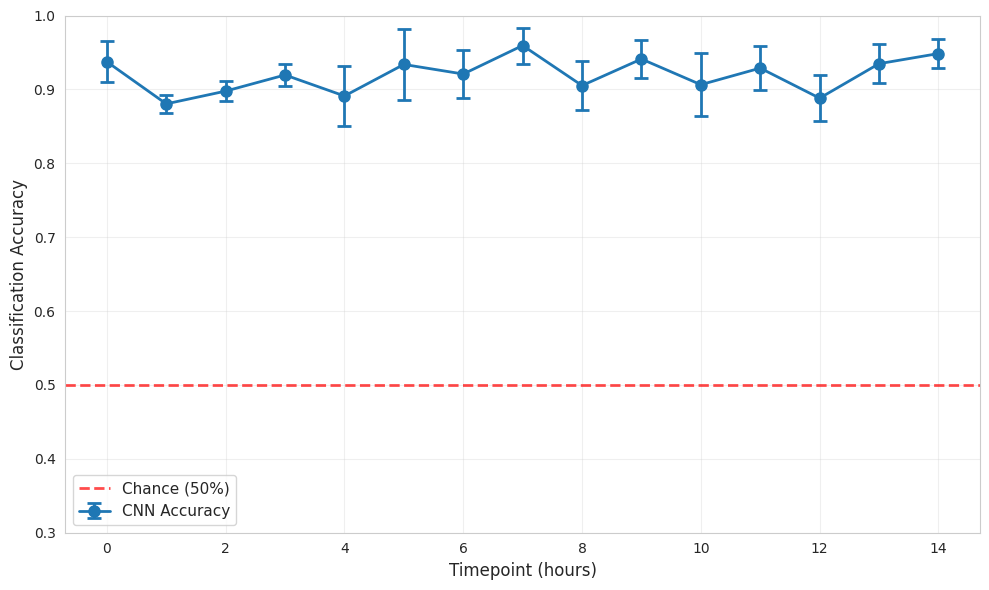

In [17]:
# Line plot: Accuracy vs Timepoint
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(df_results['timepoint'], df_results['mean_accuracy'], 
            yerr=df_results['std_accuracy'], fmt='o-', linewidth=2, 
            markersize=8, capsize=5, capthick=2, label='CNN Accuracy')

ax.axhline(y=0.5, color='r', linestyle='--', linewidth=2, label='Chance (50%)', alpha=0.7)
ax.set_xlabel('Timepoint (hours)', fontsize=12)
ax.set_ylabel('Classification Accuracy', fontsize=12)
ax.set_ylim([0.3, 1.0])
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'timecourse_accuracy_vs_timepoint.png', dpi=150)
plt.show()

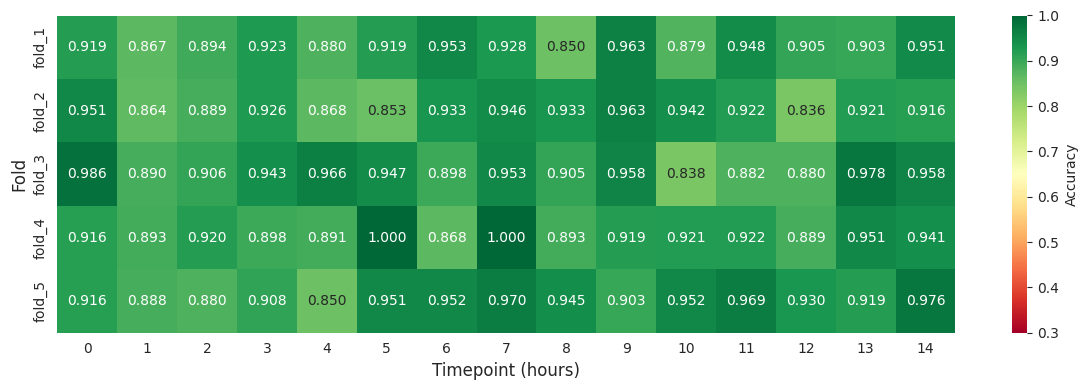

In [16]:
# Heatmap: Fold accuracies across timepoints
fold_cols = ['fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5']
heatmap_data = df_results[['timepoint'] + fold_cols].set_index('timepoint')[fold_cols].T

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.3, vmax=1.0,
            cbar_kws={'label': 'Accuracy'}, ax=ax)
ax.set_xlabel('Timepoint (hours)', fontsize=12)
ax.set_ylabel('Fold', fontsize=12)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'timecourse_accuracy_heatmap.png', dpi=150)
plt.show()